# Task 4

## Introduction
The goal of this task is to predict medical insurance charges for individuals based on personal characteristics such as age, BMI, gender, smoking status, number of children, and region. Accurate prediction helps insurers assess risk and set premiums fairly.

We will use Linear Regression and evaluate the model using MAE and RMSE. We will also analyze the effect of key features on charges to extract actionable insights.


In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
df = pd.read_csv('insurance.csv')

# Quick look at data
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Info & Summary
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

- No missing values in the dataset.
- Numerical features: age, bmi, children, charges
- Categorical features: sex, smoker, region
- Target variable: charges


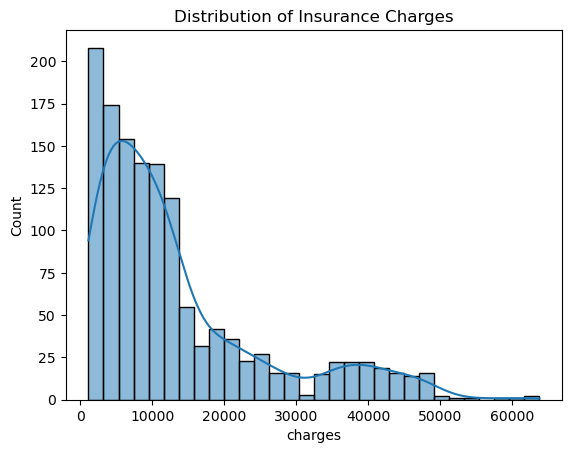

In [4]:
# Histogram of charges
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

**Insights:**

- Most charges are below $15,000, but there are **extreme outliers > 50,000**.
- Skewed distribution indicates Linear Regression may underpredict for high charges.
- Consider log transformation or robust models if needed.

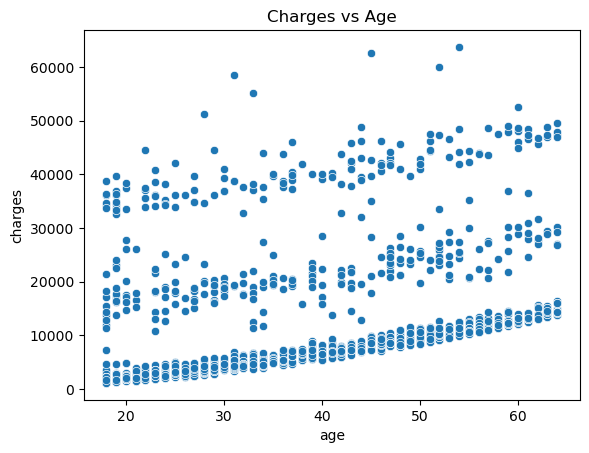

In [5]:
# Charges vs Age
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Charges vs Age')
plt.show()

**Insights:**

- There’s a positive correlation: older individuals generally have higher charges.

- Charges increase more sharply after age ~50, indicating potential non-linear effects.

- Implication: Linear model may underestimate charges for older individuals, so polynomial terms or tree-based models might capture this better.

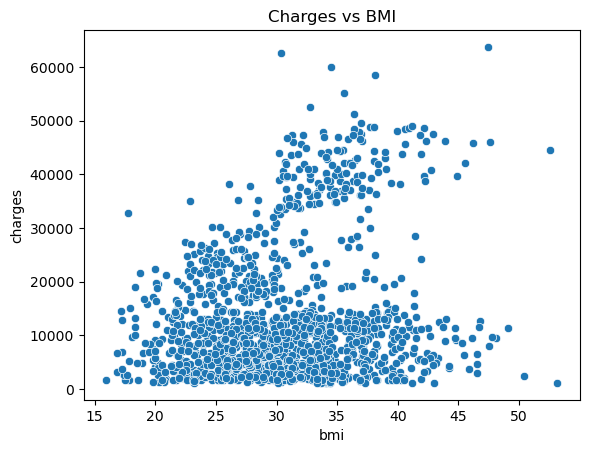

In [6]:
# Charges vs BMI
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('Charges vs BMI')
plt.show()

**Insights:**

- Moderate correlation: higher BMI tends to lead to higher charges, especially for BMIs >30 (obese category).

- Suggests BMI interacts with other factors (like smoking) — could engineer an interaction term: smoker*BMI for better prediction.

- Shows non-linear effect: Linear model may not capture sudden jumps in charges at very high BMI.

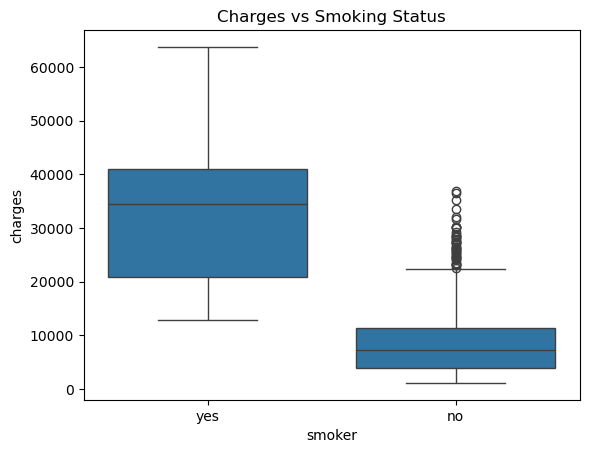

In [7]:
# Charges vs Smoker
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges vs Smoking Status')
plt.show()

**Insights:**

- Huge difference between smokers and non-smokers: median charges for smokers ~3x higher than non-smokers.

- Smoking is the strongest categorical predictor in this dataset.

- Indicates model performance will heavily depend on correctly capturing smoker effect.

## Data Preprocessing

In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Check missing values
df.isnull().sum()

# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Model Training
- Use Linear Regression
- Evaluate with MAE and RMSE

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Mean Absolute Error (MAE): 4181.19
Root Mean Squared Error (RMSE): 5796.28


**Model Evaluation Insights**

- **Mean Absolute Error (MAE): 4181.19**  
  On average, the model’s predictions are off by about **$4,181**. This gives a sense of typical prediction error for most individuals.

- **Root Mean Squared Error (RMSE): 5796.28**  
  RMSE is higher than MAE because it **penalizes larger errors more**, meaning that extreme outliers (very high charges) are not well captured by the model.

- **Interpretation:**  
  The Linear Regression model performs reasonably well for the majority of individuals, but it **tends to underpredict very high insurance charges**, especially for older individuals, smokers, or those with high BMI. This aligns with the patterns we observed in EDA.


## Conclusion & Future Improvements

### Key Takeaways:

- **Strong predictors:** smoker status, age, BMI  
  - Smokers have much higher charges than non-smokers.  
  - Older age and higher BMI also lead to higher charges, with non-linear effects at extremes.  

- **Moderate predictors:** children, sex  
  - More children slightly increase charges; males and females have minor differences.  

- **Weak predictor:** region  
  - Differences across regions are minimal; low impact on charges.  

- **Model performance:**  
  - **MAE = 4181.19** → on average, the model is off by **$4,181**.  
  - **RMSE = 5796.28** → indicates that **extreme values/outliers** are not well captured.  
  - Linear Regression works reasonably well for most individuals but **underpredicts high charges** for older smokers or very high BMI cases.  

### Future Improvements:

1. **Advanced Regression Models:**  
   - Use **Random Forest Regression** or **Gradient Boosting** to better capture non-linear patterns and outliers.

2. **Feature Engineering:**  
   - Introduce interaction terms like `smoker*BMI` or `age*smoker` to model combined effects.

3. **Outlier Handling / Transformation:**  
   - Consider **log-transforming charges** to reduce skewness.  
   - Explore **robust regression techniques** to limit the impact of extreme high charges.

4. **Model Tuning & Validation:**  
   - Perform **cross-validation** to ensure the model generalizes well.  
   - Experiment with **polynomial features** for age and BMI to capture non-linear growth in charges.

---

**Summary:**  
Linear Regression provides a solid baseline for predicting insurance charges, highlighting the importance of smoking, age, and BMI. The model’s errors (~$4k–$5.8k) suggest further improvements are possible through advanced models, feature engineering, and outlier-aware techniques.
